In [7]:
# Cell 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
# Cell 2: Load the dataset
df = pd.read_csv('car_price_dataset_cleaned.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)

Dataset shape: (9619, 15)

First 5 rows:


,Brand,Model,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price,Car_Age
0,AUDI,A1,990.0,Automatic,Petrol,99000.0,Gampaha,0,USED,1,1,1,1,100.0,9
1,AUDI,A1,1000.0,Automatic,Petrol,88000.0,Colombo,0,USED,1,1,1,1,97.0,8
2,AUDI,A1,1000.0,Automatic,Petrol,77000.0,Dehiwala-Mount-Lavinia,0,USED,1,1,1,1,98.5,7
3,AUDI,A1,1000.0,Automatic,Petrol,88000.0,Negombo,0,USED,1,1,1,1,107.0,7
4,AUDI,A1,1000.0,Automatic,Petrol,88000.0,Colombo,0,USED,1,1,1,1,99.5,7



Data types:
Brand                 str
Model                 str
Engine (cc)       float64
Gear                  str
Fuel Type             str
Millage(KM)       float64
Town                  str
Leasing               str
Condition             str
AIR CONDITION         str
POWER STEERING        str
POWER MIRROR          str
POWER WINDOW          str
Price             float64
Car_Age             int64
dtype: object


Summary Statistics:


,Brand,Model,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price,Car_Age
count,9619,9619,9619.000000,9619,9619,9619.000000,9619,9619,9619,9619,9619,9619,9619,9619.000000,9619.000000
unique,45,1477,NaN,2,4,NaN,107,2,2,2,2,2,2,NaN,NaN
top,TOYOTA,ALTO,NaN,Automatic,Petrol,NaN,Colombo,0,USED,1,1,1,1,NaN,NaN
freq,3081,392,NaN,6167,7752,NaN,983,9217,9531,9425,8775,7147,7867,NaN,NaN
mean,NaN,NaN,1251.588502,NaN,NaN,200367.189937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.382765,17.920886
std,NaN,NaN,394.899881,NaN,NaN,104650.619894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.969991,9.535930
min,NaN,NaN,600.000000,NaN,NaN,11000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.650000,0.000000
25%,NaN,NaN,1000.000000,NaN,NaN,110000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.056000,10.000000
50%,NaN,NaN,1300.000000,NaN,NaN,176000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.500000,16.000000
75%,NaN,NaN,1500.000000,NaN,NaN,264000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.000000,24.000000



Missing / 'Not_Available' count per column:
Brand                0
Model                0
Engine (cc)          0
Gear                 0
Fuel Type            0
Millage(KM)          0
Town                 0
Leasing              0
Condition            0
AIR CONDITION      194
POWER STEERING     844
POWER MIRROR      2472
POWER WINDOW      1752
Price                0
Car_Age              0
dtype: int64


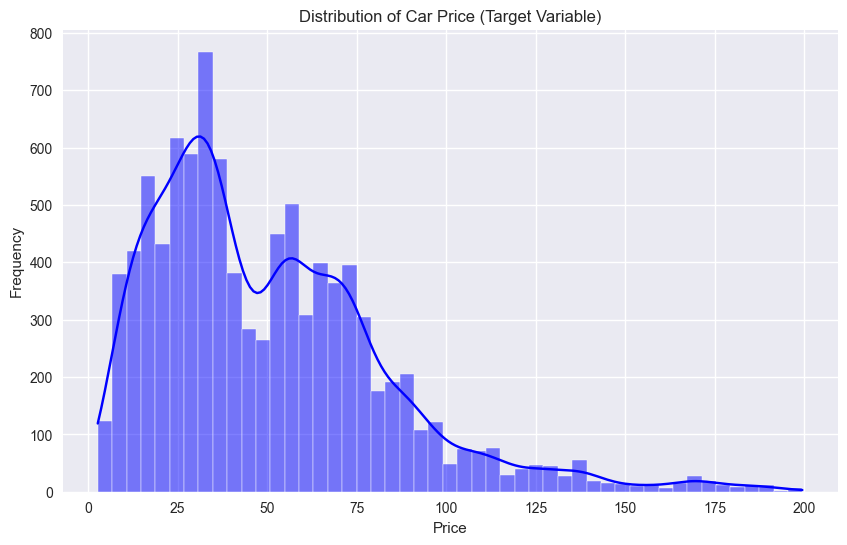

In [9]:
# Cell 3: Basic EDA - Summary statistics and missing values check
print("Summary Statistics:")
display(df.describe(include='all'))

print("\nMissing / 'Not_Available' count per column:")
print((df == 'Not_Available').sum())

# Quick check for target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Car Price (Target Variable)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [10]:
# Cell 4: Data Cleaning - Handle 'Not_Available', Leasing, and binary features
# Binary features (1 / Not_Available) → convert to 0/1 integers
binary_cols = ['AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']
for col in binary_cols:
    df[col] = df[col].replace('Not_Available', 0)
    df[col] = df[col].replace('1', 1).astype(int)

# Leasing: '0' → 0, 'Ongoing Lease' → 1
df['Leasing'] = df['Leasing'].replace({'0': 0, 'Ongoing Lease': 1}).astype(int)

# Condition remains categorical (NEW / USED)
print("Cleaned binary features sample:")
display(df[binary_cols + ['Leasing', 'Condition']].head())

print("\nNo more 'Not_Available' in binary columns!")
print((df == 'Not_Available').sum())

Cleaned binary features sample:


,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Leasing,Condition
0,1,1,1,1,0,USED
1,1,1,1,1,0,USED
2,1,1,1,1,0,USED
3,1,1,1,1,0,USED
4,1,1,1,1,0,USED



No more 'Not_Available' in binary columns!
Brand             0
Model             0
Engine (cc)       0
Gear              0
Fuel Type         0
Millage(KM)       0
Town              0
Leasing           0
Condition         0
AIR CONDITION     0
POWER STEERING    0
POWER MIRROR      0
POWER WINDOW      0
Price             0
Car_Age           0
dtype: int64


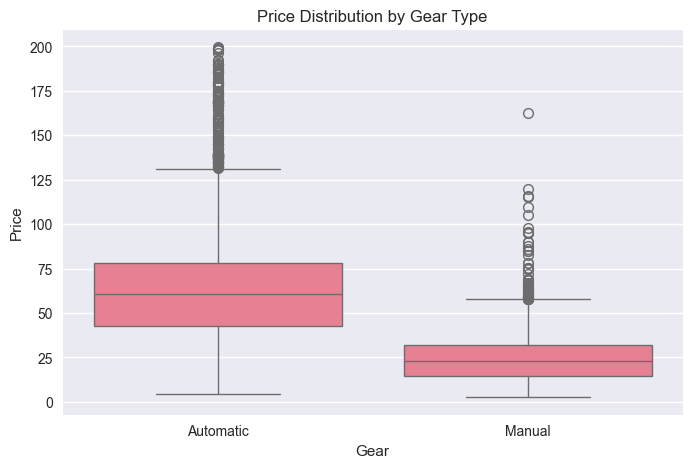

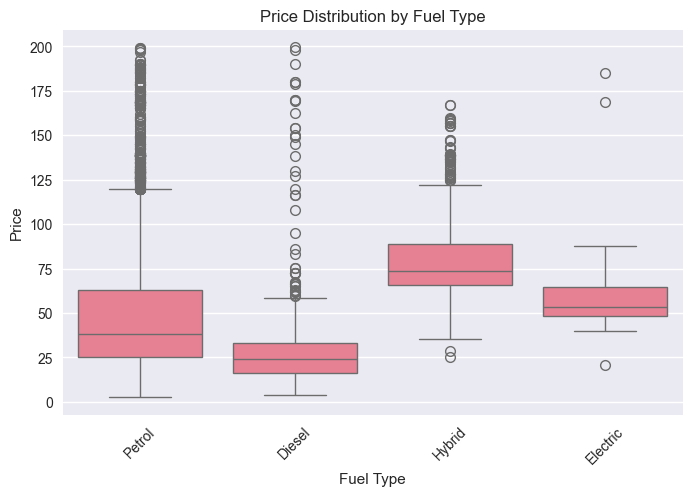

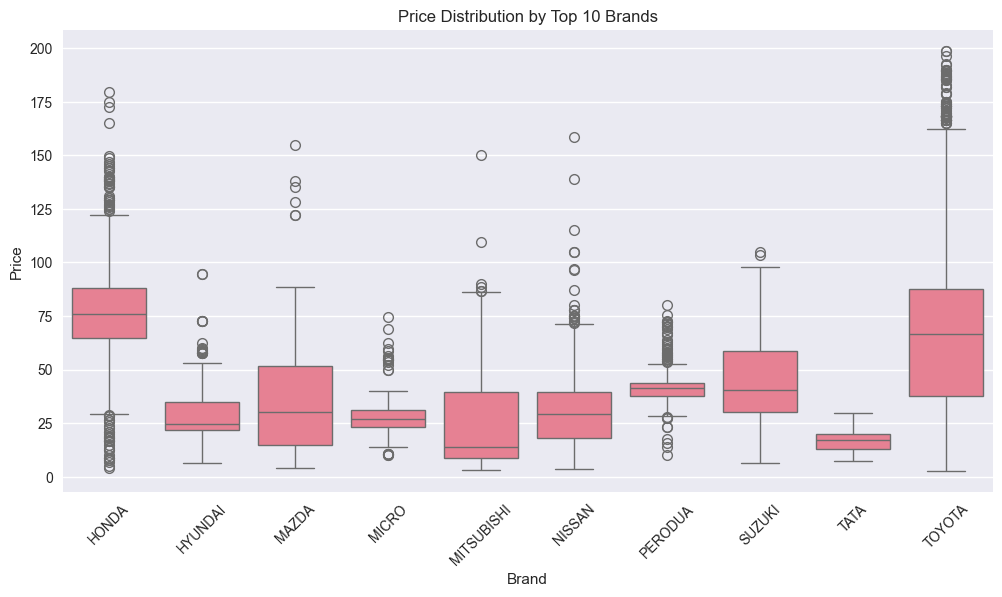

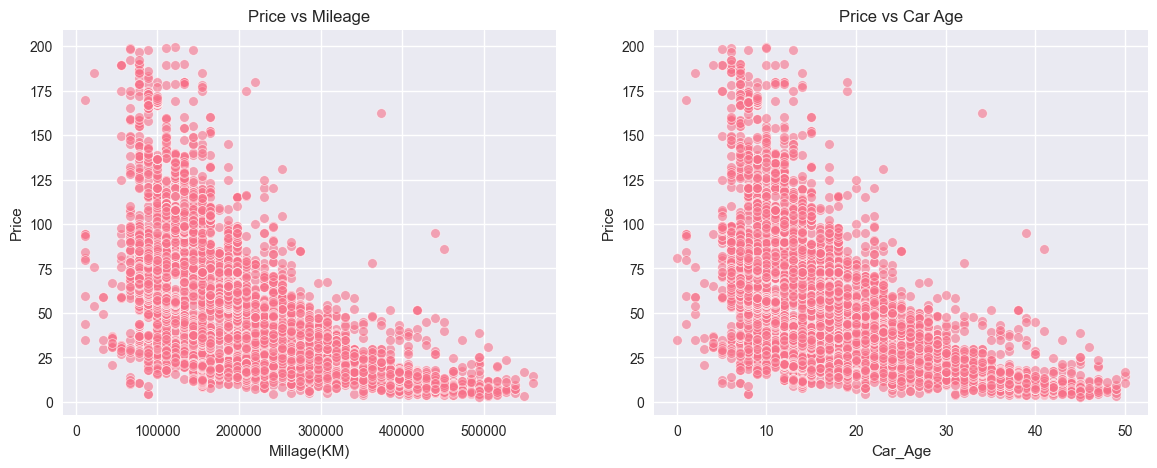

In [11]:
# Cell 5: More EDA Visualizations (Boxplots & Scatter plots)
# Boxplot: Price by Gear
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gear', y='Price', data=df)
plt.title('Price Distribution by Gear Type')
plt.show()

# Boxplot: Price by Fuel Type
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel Type', y='Price', data=df)
plt.title('Price Distribution by Fuel Type')
plt.xticks(rotation=45)
plt.show()

# Top 10 Brands price boxplot
top_brands = df['Brand'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price', data=df[df['Brand'].isin(top_brands)])
plt.title('Price Distribution by Top 10 Brands')
plt.xticks(rotation=45)
plt.show()

# Scatter: Price vs Mileage & Car Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='Millage(KM)', y='Price', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Price vs Mileage')
sns.scatterplot(x='Car_Age', y='Price', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('Price vs Car Age')
plt.show()

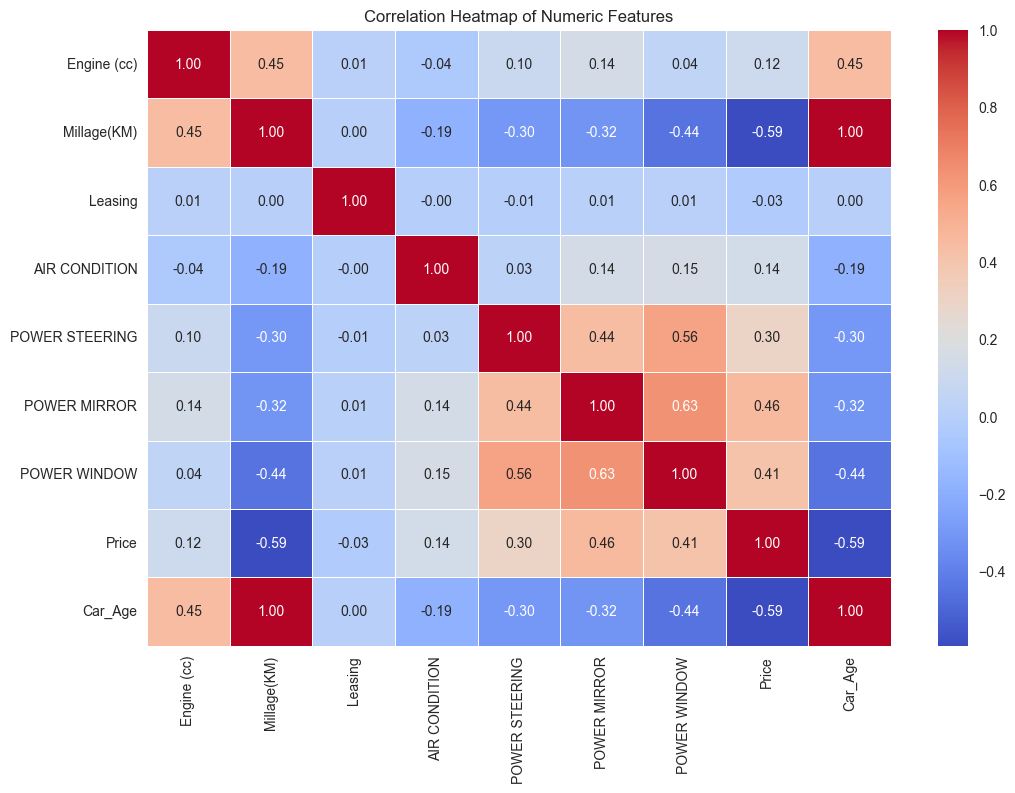

Strongest correlations with Price:
Price             1.000000
POWER MIRROR      0.457821
POWER WINDOW      0.411099
POWER STEERING    0.303167
AIR CONDITION     0.135599
Engine (cc)       0.115585
Leasing          -0.027916
Car_Age          -0.590821
Millage(KM)      -0.592700
Name: Price, dtype: float64


In [12]:
# Cell 6: Correlation Heatmap (Numeric features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

print("Strongest correlations with Price:")
print(corr_matrix['Price'].sort_values(ascending=False))

In [13]:
# Cell 7: Prepare features for modeling
# Define feature lists
num_features = ['Engine (cc)', 'Millage(KM)', 'Car_Age', 'Leasing', 
                'AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']
cat_features = ['Brand', 'Model', 'Gear', 'Fuel Type', 'Town', 'Condition']

X = df.drop('Price', axis=1)
y = df['Price']

print(f"Features: {X.shape[1]} columns")
print(f"Numeric: {len(num_features)} | Categorical: {len(cat_features)}")

Features: 14 columns
Numeric: 8 | Categorical: 6


In [14]:
# Cell 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 7695 samples
Test set: 1924 samples


In [17]:
# NEW CELL - Insert before your old Cell 9
# Diagnostic: Check cardinality of categorical columns
cat_cols = ['Brand', 'Model', 'Gear', 'Fuel Type', 'Town', 'Condition']
for col in cat_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")

Brand: 45 unique values
Model: 1295 unique values
Gear: 2 unique values
Fuel Type: 4 unique values
Town: 106 unique values
Condition: 2 unique values


In [18]:
# UPDATED CELL 9: Fixed Preprocessor + Model Pipeline (High-Cardinality Fix)
# Separate high-cardinality 'Model' so it is NOT treated as categorical

low_card_cats = ['Brand', 'Gear', 'Fuel Type', 'Town', 'Condition']   # <= 255 categories
high_card     = ['Model']                                             # 1477 categories

preprocessor = ColumnTransformer(
    transformers=[
        ('num',      StandardScaler(), num_features),
        ('high_card', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), high_card),
        ('low_card',  OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), low_card_cats)
    ],
    remainder='drop'
)

# Model (now with safe categorical_features indices)
model = HistGradientBoostingRegressor(
    random_state=42,
    max_bins=255,                    # default is fine now
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    categorical_features=range(len(num_features) + len(high_card), 
                               len(num_features) + len(high_card) + len(low_card_cats))
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', model)
])

print("✅ Fixed pipeline created! (Model is now handled as high-cardinality numeric feature)")

✅ Fixed pipeline created! (Model is now handled as high-cardinality numeric feature)


In [19]:
# Cell 10: Initial Model Training (Baseline) - Run again
pipeline.fit(X_train, y_train)
y_pred_baseline = pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2   = r2_score(y_test, y_pred_baseline)

print("=== BASELINE MODEL PERFORMANCE ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f} ({r2*100:.2f}%)")

=== BASELINE MODEL PERFORMANCE ===
MAE:  5.21
RMSE: 10.37
R²:   0.9014 (90.14%)


In [20]:
# Cell 11: Fine-Tuning (RandomizedSearchCV) - Now works without error
# (You can increase n_iter=30~50 for even higher accuracy if you have time)

param_dist = {
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_iter': [200, 300, 400],
    'regressor__max_depth': [None, 10, 15, 20],
    'regressor__min_samples_leaf': [1, 5, 10, 20],
    'regressor__l2_regularization': [0, 0.1, 1.0],
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=25,          # ← you can raise this
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("\n✅ Best parameters:", random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.4f}")

Starting hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Best parameters: {'regressor__min_samples_leaf': 1, 'regressor__max_iter': 400, 'regressor__max_depth': 20, 'regressor__learning_rate': 0.1, 'regressor__l2_regularization': 1.0}
Best CV R²: 0.9191
